In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from snntorch.surrogate import fast_sigmoid
import numpy as np
from tqdm.auto import tqdm
import psutil, os

from thesis_code import SRNN, datasets
from thesis_code.network_components.layers import StandardRecurrentLayer, OutputLayer
from thesis_code.decay_sampling import sample_heterogeneous_decays_normal, tau_to_beta

from thesis_code.recording import SpikeRecorder, PerformanceRecorder, GradientRecorder
import thesis_code.training as tr
from thesis_code.plotting import plot_performance, plot_gradients, InteractiveSpikePlot

In [2]:
flushing = torch.set_flush_denormal(True)
print(f"Floating point flushing is set to {flushing}")

torch.manual_seed(42)
torch.set_num_threads(4)
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Using device: {device}")

Floating point flushing is set to True
Using device: cpu


In [3]:
def train_net(net: SRNN, trainloader: DataLoader, lr: float = 1e-3, n_epochs: int = 1, max_iters: int = None, separate_timesteps: bool = False,
        regularizer: tr.Regularizer = None, grad_rec: GradientRecorder = None, spk_rec: SpikeRecorder = None,
    ) -> tuple[nn.Module, PerformanceRecorder, GradientRecorder | None, SpikeRecorder | None]:
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    process = psutil.Process(os.getpid())
    perf_rec = PerformanceRecorder()

    use_amp = device.type == "cuda"

    net.train()

    for epoch in range(n_epochs):
        progress_bar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"Epoch {epoch}")
        losses, accs = [], []
        for i, (data, targets) in progress_bar:

            forward_fn = net.forward_sequence if separate_timesteps else net
            with torch.autocast(device.type, dtype=torch.bfloat16, enabled=use_amp):
                spk_outs, mem_outs, hidden_spks = forward_fn(data)

            loss_val = tr.compute_loss(mem_outs, targets)
            
            if regularizer is not None:
                loss_val = loss_val +  regularizer(hidden_spks)

            if spk_rec is not None:
                spk_rec.record(data, hidden_spks, spk_outs, targets)

            optimizer.zero_grad()
            loss_val.backward()

            if grad_rec is not None:
                grad_rec.record(net)

            optimizer.step()

            losses.append(loss_val.item())
            acc = tr.measure_accuracy(mem_outs.detach(), targets)
            accs.append(acc)

            progress_bar.set_postfix(
                loss=f"{loss_val.item():.2f}",
                acc=f"{acc * 100:.2f}%",
                time_elapsed=f"{progress_bar.format_dict['elapsed']:.1f}s",
                used_memory=f"{process.memory_info().rss / 1e9:.2f} GB",
            )

            if max_iters is not None and i == max_iters:
                break

        perf_rec.record(float(np.mean(losses)), float(np.mean(accs)))
    return net, perf_rec, grad_rec, spk_rec

In [4]:
dt = 0.01     # Timesteps are in milliseconds
batch_size = 128
SHD_trainloader, SHD_testloader, input_dim, classes = datasets.get_SHD_dataset(batch_size, device, time_window=10000)

regularizer = tr.Regularizer(lam_lower=100.0, v_lower=1e-2, lam_uppers=[0.5, 0.5], v_uppers=[50, 50], L=2)

In [5]:
from thesis_code.connectivity import sample_ee_pv_som_neurons, build_recurrent_matrix, build_recurrent_and_pruned_matrices

ns_hidden=[256, 256]
layers = [input_dim] + ns_hidden
n_trials = 5

def build_srnn(rec_matrices: list[torch.Tensor], betas: list[torch.Tensor]) -> SRNN:
    return SRNN(
        rec_layers=[
            StandardRecurrentLayer(
                forward_matrix=torch.ones(n_prev, n).to(device),
                recurrent_matrix=rec_matrix.to(device),
                beta=beta.clone().to(device),
                spike_grad=fast_sigmoid(slope=25),
            ) for n_prev, n, rec_matrix, beta in zip(layers[:-1], layers[1:], rec_matrices, betas)],
        out_layer=OutputLayer(
            n_in=layers[-1],
            n_out=len(classes),
            beta=tau_to_beta(dt, 20 * dt),
        ),
    )

losses, accs, losses_pruned, accs_pruned = [], [], [], []
perf_recs_pruned = []
for trial in range(n_trials):
    neurons = sample_ee_pv_som_neurons(ns_hidden, percent_pv=25.0, percent_som=25.0)
    rec_matrices, pruned_matrices = build_recurrent_and_pruned_matrices(neurons)

    print(f"Trial: {trial}")
    for rm, pm in zip(rec_matrices, pruned_matrices):
        print(f"shapes are equal = {rm.shape == pm.shape}")
        print(f"number of connections = {np.prod(rm.shape)} and {np.prod(pm.shape)}")
        print(f"number of alive connections = {rm.count_nonzero()} and {pm.count_nonzero()}")

        for v in (-1, 0, 1):
            assert (rm == v).sum() == (pm == v).sum(), f"mismatch for value {v}"

    betas = [sample_heterogeneous_decays_normal(dt, n, tau_mean=10 * dt, tau_std=1 * dt, device=device) for n in ns_hidden]
    net = build_srnn(rec_matrices, betas).to(device)
    pruned_net = build_srnn(pruned_matrices, betas).to(device)

    net, perf_rec, _, _ = train_net(
        net=net,
        trainloader=SHD_trainloader,
        lr=1e-3,
        n_epochs=10,
        max_iters=None,
        separate_timesteps=False,
        regularizer=regularizer,
        # grad_rec=GradientRecorder(),
        # spk_rec=SpikeRecorder(num_hidden_layers=len(ns_hidden)),
    )
    loss_hist, acc_hist = perf_rec.get_performance()
    losses.append(loss_hist)
    accs.append(acc_hist)

    pruned_net, perf_rec_pruned, _, _ = train_net(
        net=pruned_net,
        trainloader=SHD_trainloader,
        lr=1e-3,
        n_epochs=10,
        max_iters=None,
        separate_timesteps=False,
        regularizer=regularizer,
        # grad_rec=GradientRecorder(),
        # spk_rec=SpikeRecorder(num_hidden_layers=len(ns_hidden)),
    )
    loss_hist_pruned, acc_hist_pruned = perf_rec_pruned.get_performance()
    losses_pruned.append(loss_hist_pruned)
    accs_pruned.append(acc_hist_pruned)

    del net
    del perf_rec
    del pruned_net
    del perf_rec_pruned
    torch.cuda.empty_cache()

Trial: 0
shapes are equal = True
number of connections = 65536 and 65536
number of alive connections = 61717 and 61717
shapes are equal = True
number of connections = 65536 and 65536
number of alive connections = 62057 and 62057


Epoch 0:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch 5:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 6:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 7:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 8:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 9:   0%|          | 0/63 [00:00<?, ?it/s]

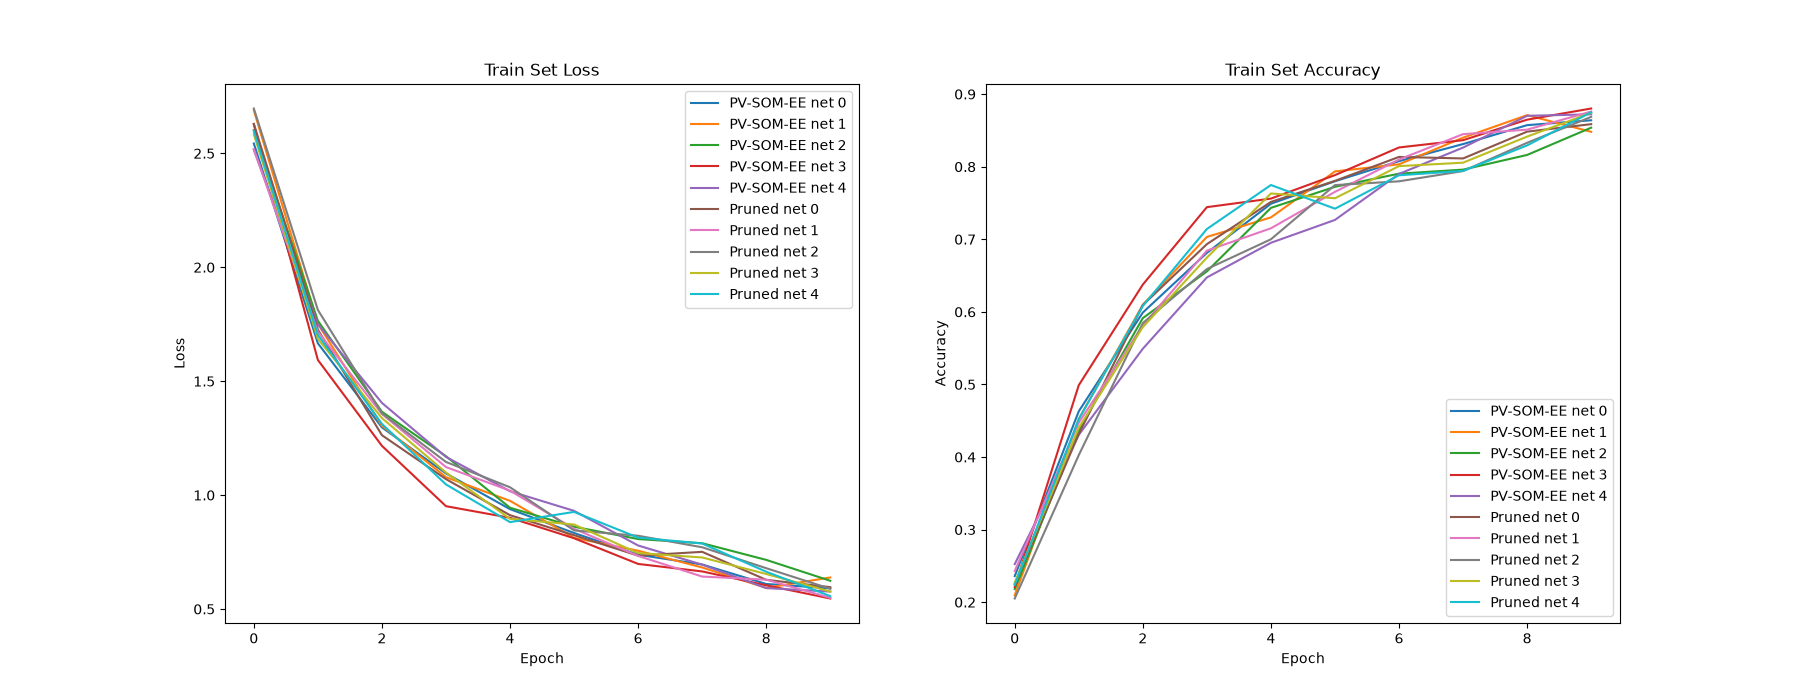

In [7]:
import matplotlib.pyplot as plt

fig, (ax_loss, ax_acc) = plt.subplots(nrows=1, ncols=2, facecolor='w', figsize=(18, 7))

for i, loss_hist in enumerate(losses):
    ax_loss.plot(loss_hist, label=f"PV-SOM-EE net {i}")
for i, loss_hist in enumerate(losses_pruned):
    ax_loss.plot(loss_hist, label=f"Pruned net {i}")
ax_loss.set_title("Train Set Loss")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss")
ax_loss.legend()

for i, acc_hist in enumerate(accs):
    ax_acc.plot(acc_hist, label=f"PV-SOM-EE net {i}")
for i, acc_hist in enumerate(accs_pruned):
    ax_acc.plot(acc_hist, label=f"Pruned net {i}")
ax_acc.set_title("Train Set Accuracy")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy")
ax_acc.legend()

plt.show()

[]

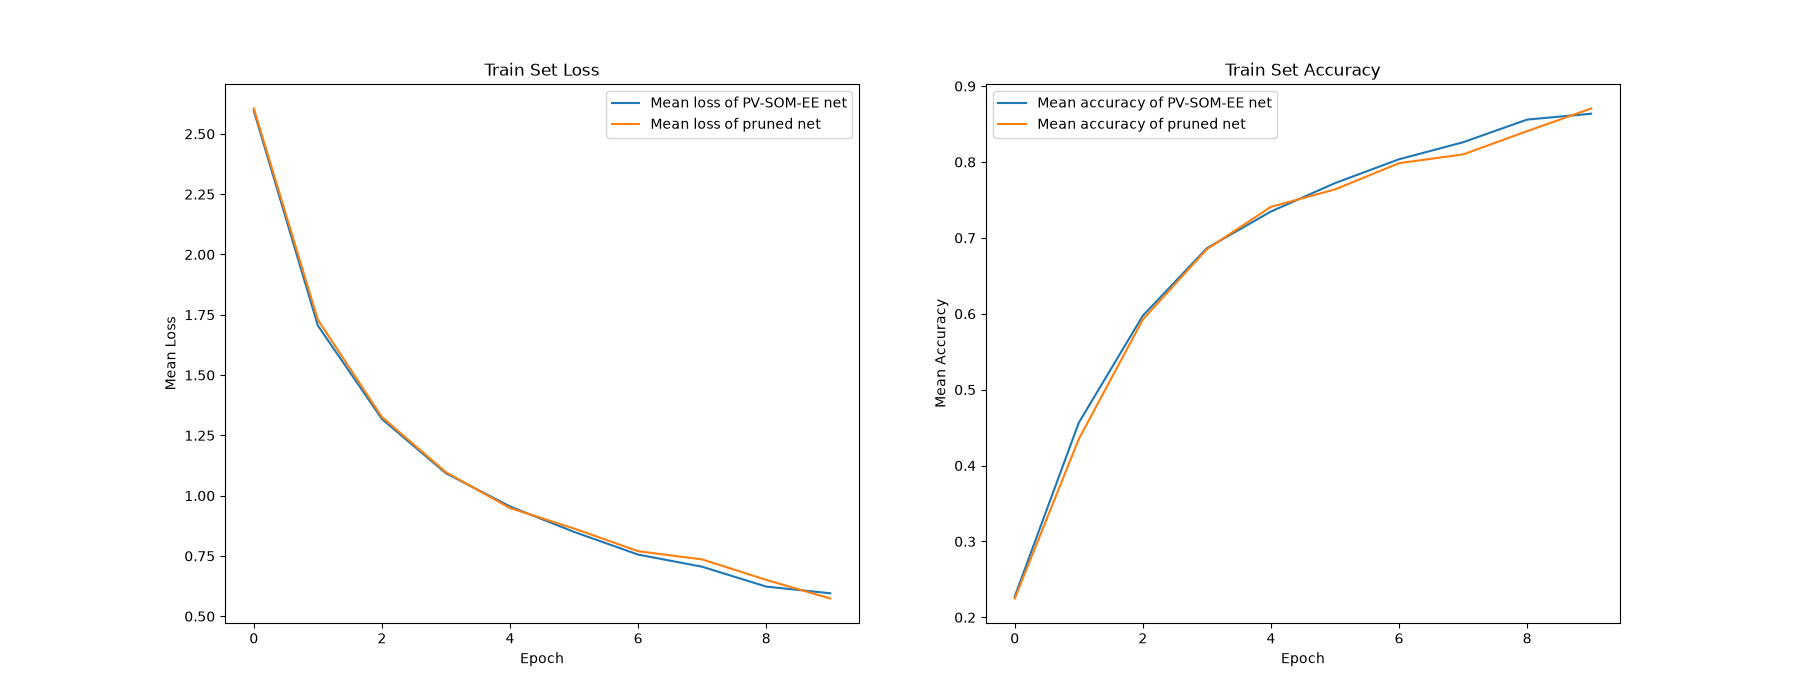

In [10]:
fig, (ax_loss, ax_acc) = plt.subplots(nrows=1, ncols=2, facecolor='w', figsize=(18, 7))

ax_loss.plot(np.mean(losses, axis=0), label=f"Mean loss of PV-SOM-EE net")
ax_loss.plot(np.mean(losses_pruned, axis=0), label=f"Mean loss of pruned net")
ax_loss.set_title("Train Set Loss")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Mean Loss")
ax_loss.legend()

ax_acc.plot(np.mean(accs, axis=0), label=f"Mean accuracy of PV-SOM-EE net")
ax_acc.plot(np.mean(accs_pruned, axis=0), label=f"Mean accuracy of pruned net")
ax_acc.set_title("Train Set Accuracy")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Mean Accuracy")
ax_acc.legend()
plt.plot()